In [59]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**RUN THIS TO RETRIEVE DATASET**

In [60]:
%cd /content
!git clone https://github.com/fengbolan/York-Fisheye-Image-Rectification-Dataset.git


/content
fatal: destination path 'York-Fisheye-Image-Rectification-Dataset' already exists and is not an empty directory.


In [61]:
print("Copying Chair folder...")
# -n (noclobber) skips if it's already there
!cp -r -n /content/York-Fisheye-Image-Rectification-Dataset/Chair /content/drive/MyDrive/FCV_PROJECT/

print("Copying Cigarette box folder...")
# Note the quotation marks because of the space in the name
!cp -r -n /content/York-Fisheye-Image-Rectification-Dataset/"Cigarette box" /content/drive/MyDrive/FCV_PROJECT/

print("Copying Skull folder...")
!cp -r -n /content/York-Fisheye-Image-Rectification-Dataset/Skull /content/drive/MyDrive/FCV_PROJECT/

print("Copying Teddy folder...")
!cp -r -n /content/York-Fisheye-Image-Rectification-Dataset/Teddy /content/drive/MyDrive/FCV_PROJECT/

print("\n✅ All 4 folders are now in /content/drive/MyDrive/FCV_PROJECT/")

Copying Chair folder...
Copying Cigarette box folder...
Copying Skull folder...
Copying Teddy folder...

✅ All 4 folders are now in /content/drive/MyDrive/FCV_PROJECT/


In [62]:
import os
os.listdir('/content/drive/MyDrive/FCV_PROJECT')


['Chair', 'Cigarette box', 'Skull', 'Teddy']

***Only execute for teddy***

In [50]:
import os

# List of all files you want to delete
files_to_delete = [
    "/content/drive/MyDrive/FCV_PROJECT/Teddy/fisheye/fisheye.mp4",
    "/content/drive/MyDrive/FCV_PROJECT/Teddy/perspective/perspective.mp4"
]

print("Attempting to delete video files...")

# Loop through the list and delete each file
for file_path in files_to_delete:
    print(f"  Deleting: {file_path}")
    try:
        os.remove(file_path)
        print("    ✅ File successfully deleted.")
    except FileNotFoundError:
        print("    ⚠️ File was not found (it might already be deleted).")
    except Exception as e:
        print(f"    ❌ An error occurred: {e}")

print("\nDeletion process complete.")

Attempting to delete video files...
  Deleting: /content/drive/MyDrive/FCV_PROJECT/Teddy/fisheye/fisheye.mp4
    ⚠️ File was not found (it might already be deleted).
  Deleting: /content/drive/MyDrive/FCV_PROJECT/Teddy/perspective/perspective.mp4
    ⚠️ File was not found (it might already be deleted).

Deletion process complete.


**Imports**


In [63]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Import metrics for the final evaluation
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

**Define correct folder names**

In [64]:
import os

# --- 1. Define your data paths based on your folder structure ---
base_dir = "/content/drive/MyDrive/FCV_PROJECT/Chair"
fisheye_dir = os.path.join(base_dir, "fisheye")
gt_dir = os.path.join(base_dir, "perspective") # <-- FIX: Using 'perspective' as Ground Truth

# --- 2. Create an output directory ---
output_dir = os.path.join(base_dir, "corrected")
os.makedirs(output_dir, exist_ok=True)

# --- 3. Get the sorted file lists ---
print("Finding files...")
fisheye_files = sorted(os.listdir(fisheye_dir))
gt_files = sorted(os.listdir(gt_dir)) # This will now look in the 'perspective' folder

print(f"Found {len(fisheye_files)} fisheye images in {fisheye_dir}")
print(f"Found {len(gt_files)} ground truth images in {gt_dir}")

Finding files...
Found 10 fisheye images in /content/drive/MyDrive/FCV_PROJECT/Chair/fisheye
Found 10 ground truth images in /content/drive/MyDrive/FCV_PROJECT/Chair/perspective


**FINAL BEST MODEL->
Polynoial 9-params model with Gradient Descent**





**Cell Loader**


In [65]:
import cv2
import numpy as np

# (We assume fisheye_files, gt_files, fisheye_dir, gt_dir are
#  all defined in your original cell1)

print("Loading images into memory...")
fisheye_images = []
gt_images_gray = []

# Check if file lists are empty
if not fisheye_files or not gt_files:
    print("❌ ERROR: File lists are empty. Did you run cell 1 correctly?")
else:
    for i in range(len(fisheye_files)):
        f_path = os.path.join(fisheye_dir, fisheye_files[i])
        g_path = os.path.join(gt_dir, gt_files[i])

        # Load fisheye image
        img = cv2.imread(f_path)
        if img is not None:
            fisheye_images.append(img)
        else:
            print(f"Warning: Could not read {f_path}")

        # Load ground truth image and convert to grayscale
        gt_img = cv2.imread(g_path)
        if gt_img is not None:
            gt_gray = cv2.cvtColor(gt_img, cv2.COLOR_BGR2GRAY)
            gt_images_gray.append(gt_gray)
        else:
            print(f"Warning: Could not read {g_path}")

    if fisheye_images:
        print(f"✅ Loaded {len(fisheye_images)} fisheye images.")
        print(f"✅ Loaded {len(gt_images_gray)} grayscale ground truth images.")

        # This is the line that failed before. It should work now.
        h, w = fisheye_images[0].shape[:2]
        print(f"Image dimensions check: {h}x{w}")
    else:
        print("❌ ERROR: No images were loaded. Check your file paths in cell 1.")

Loading images into memory...
✅ Loaded 10 fisheye images.
✅ Loaded 10 grayscale ground truth images.
Image dimensions check: 512x512


In [66]:
# --- 1. Your 9-Parameter Correction Function (No change here) ---
def standard_model_correction(img, k1, k2, p1, p2, k3, fx, fy, cx, cy):
    h, w = img.shape[:2]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float32)
    D = np.array([k1, k2, p1, p2, k3], dtype=np.float32)

    # Let's try alpha=1 here to retain potentially more corner data
    # and see if it helps with straightening.
    new_K, roi = cv2.getOptimalNewCameraMatrix(K, D, (w,h), alpha=1, newImgSize=(w,h))

    if new_K[0,0] <= 0 or new_K[1,1] <= 0:
        return np.zeros_like(img), None

    map1, map2 = cv2.initUndistortRectifyMap(K, D, np.eye(3), new_K, (w,h), cv2.CV_16SC2)
    undistorted = cv2.remap(img, map1, map2, interpolation=cv2.INTER_LINEAR)

    return undistorted, roi


***STAGE-1***


In [67]:
import cv2
import numpy as np

# --- 2. Create the Weight Map (INCREASED edge_weight) ---
h, w = fisheye_images[0].shape[:2]
center_x, center_y = w / 2, h / 2
y, x = np.indices((h, w))
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
max_dist = np.sqrt(center_x**2 + center_y**2)
edge_weight = 4.0  # <--- INCREASED THIS VALUE (was 2.0)
weight_map = 1.0 + (dist_from_center / max_dist) * edge_weight
print(f"Created weight map with edge_weight={edge_weight} to prioritize edges even more.")

# --- 3. The 9-Parameter Loss Function (No change here) ---
def loss_9_param(params):
    k1, k2, p1, p2, k3, fx, fy, cx, cy = params

    total_loss = 0
    PENALTY_VALUE = 1e9

    for i in range(len(fisheye_images)):
        fisheye_img = fisheye_images[i]
        gt_gray = gt_images_gray[i]

        corrected_img, roi = standard_model_correction(fisheye_img,
                                                      k1, k2, p1, p2, k3,
                                                      fx, fy, cx, cy)

        mask = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2GRAY) > 0
        corrected_gray = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2GRAY)

        if np.sum(mask) == 0:
            total_loss += PENALTY_VALUE
        else:
            pixel_errors_squared = (gt_gray[mask] - corrected_gray[mask])**2
            weighted_errors = weight_map[mask] * pixel_errors_squared
            weighted_mse_loss = np.mean(weighted_errors)
            total_loss += weighted_mse_loss

    return total_loss / len(fisheye_images)

print("✅ All 9-parameter helper functions defined.")


Created weight map with edge_weight=4.0 to prioritize edges even more.
✅ All 9-parameter helper functions defined.


***STAGE-2***

In [68]:
from scipy.optimize import minimize

h, w = fisheye_images[0].shape[:2]

# --- STAGE 1: Simple "Grid Search" for k1 and k2 ---
print("--- 🚀 STAGE 1: Starting simple search for a good (k1, k2) guess ---")

# Let's try an even wider range for k1/k2 initial guesses
k1_guesses = [-0.8, -0.6, -0.4, -0.2, 0.0]
k2_guesses = [-0.1, 0.0, 0.05, 0.1, 0.2]

best_guess_loss = float('inf')
best_guess_params = []

base_params = [0.0, 0.0, 0.0, 0.0, 0.0, w/2, w/2, w/2, h/2]

for k1_guess in k1_guesses:
    for k2_guess in k2_guesses:

        test_params = base_params.copy()
        test_params[0] = k1_guess # Set k1
        test_params[1] = k2_guess # Set k2

        loss_val = loss_9_param(test_params)
        print(f"  Testing k1={k1_guess:.1f}, k2={k2_guess:.2f} ... Loss: {loss_val:.2f}")

        if loss_val < best_guess_loss:
            best_guess_loss = loss_val
            best_guess_params = test_params

print(f"✅ STAGE 1 Complete. Best starting guess: {best_guess_params} (Loss: {best_guess_loss:.2f})")

# --- STAGE 2: Full Optimization using the Smart Start ---
print("\n--- 🚀 STAGE 2: Starting full 9-parameter optimization ---")

# BOUNDS: Made k1, k2, k3 bounds wider to allow for more extreme distortion.
param_bounds = [
    (-3.0, 3.0), (-3.0, 3.0), # k1, k2 (Wider bounds)
    (-0.2, 0.2), (-0.2, 0.2), # p1, p2 (Slightly wider)
    (-3.0, 3.0),             # k3 (Wider bounds)
    (w * 0.2, w * 3.0), (w * 0.2, w * 3.0), # fx, fy (Wider for more flexibility)
    (w * 0.3, w * 0.7), (h * 0.3, h * 0.7)  # cx, cy (Slightly wider center bounds)
]

result = minimize(
    loss_9_param,
    x0=best_guess_params, # <-- Use our smart start!
    bounds=param_bounds,
    method='L-BFGS-B',
    options={'maxiter': 500, 'disp': True, 'eps': 1e-7}
)

best_params_final_9 = result.x
print(f"✅ STAGE 2 Complete. Final 9 params: {best_params_final_9}")


--- 🚀 STAGE 1: Starting simple search for a good (k1, k2) guess ---
  Testing k1=-0.8, k2=-0.10 ... Loss: 255.08
  Testing k1=-0.8, k2=0.00 ... Loss: 241.47
  Testing k1=-0.8, k2=0.05 ... Loss: 352.33
  Testing k1=-0.8, k2=0.10 ... Loss: 222.12
  Testing k1=-0.8, k2=0.20 ... Loss: 302.08
  Testing k1=-0.6, k2=-0.10 ... Loss: 211.58
  Testing k1=-0.6, k2=0.00 ... Loss: 175.58
  Testing k1=-0.6, k2=0.05 ... Loss: 150.19
  Testing k1=-0.6, k2=0.10 ... Loss: 200.38
  Testing k1=-0.6, k2=0.20 ... Loss: 182.80
  Testing k1=-0.4, k2=-0.10 ... Loss: 138.88
  Testing k1=-0.4, k2=0.00 ... Loss: 94.88
  Testing k1=-0.4, k2=0.05 ... Loss: 182.20
  Testing k1=-0.4, k2=0.10 ... Loss: 196.23
  Testing k1=-0.4, k2=0.20 ... Loss: 192.92
  Testing k1=-0.2, k2=-0.10 ... Loss: 117.85
  Testing k1=-0.2, k2=0.00 ... Loss: 141.72
  Testing k1=-0.2, k2=0.05 ... Loss: 224.07
  Testing k1=-0.2, k2=0.10 ... Loss: 204.85
  Testing k1=-0.2, k2=0.20 ... Loss: 187.79
  Testing k1=0.0, k2=-0.10 ... Loss: 218.21
  Tes

/tmp/ipython-input-4291032333.py:45: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


✅ STAGE 2 Complete. Final 9 params: [ -0.4   0.    0.    0.    0.  256.  256.  256.  256. ]


**OUTPUTS**

🚀 Applying FINAL optimized 9-parameter correction to all images...


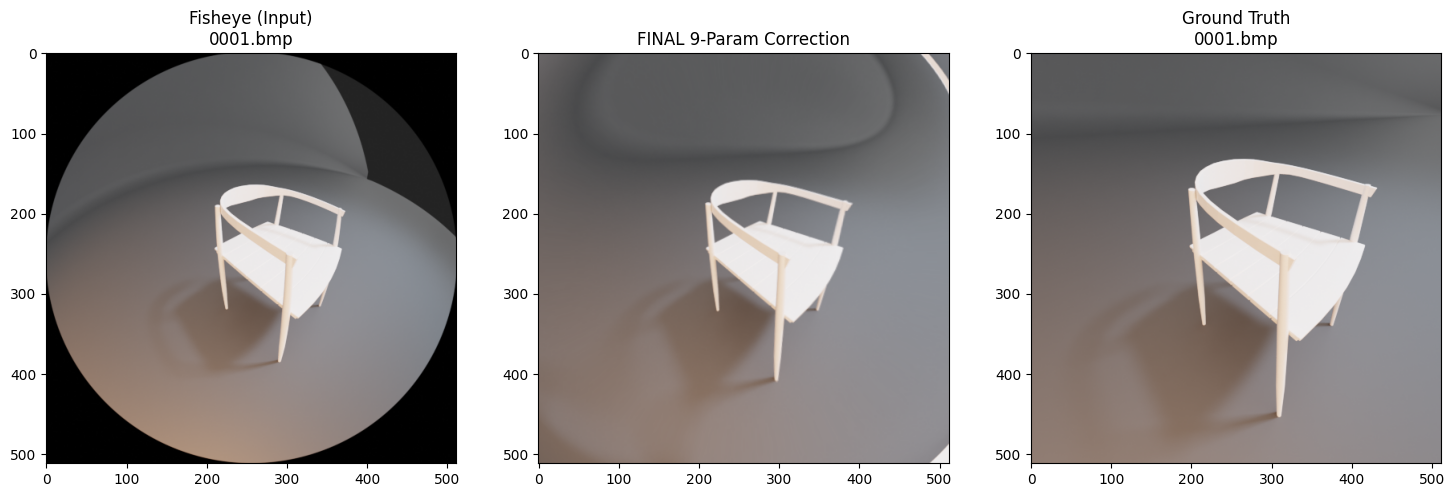

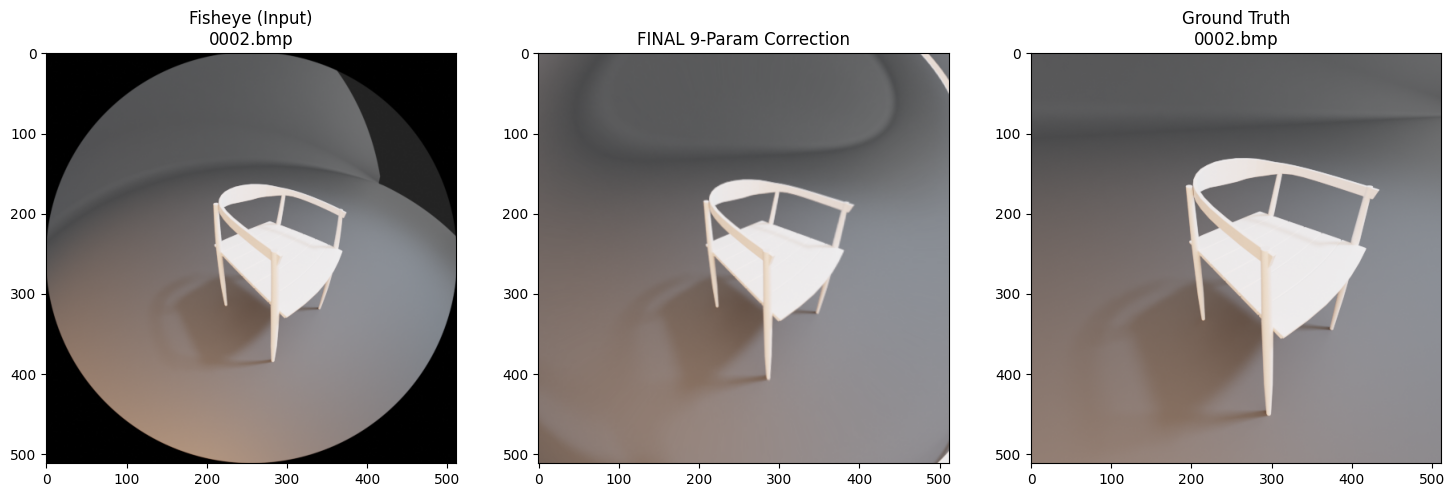

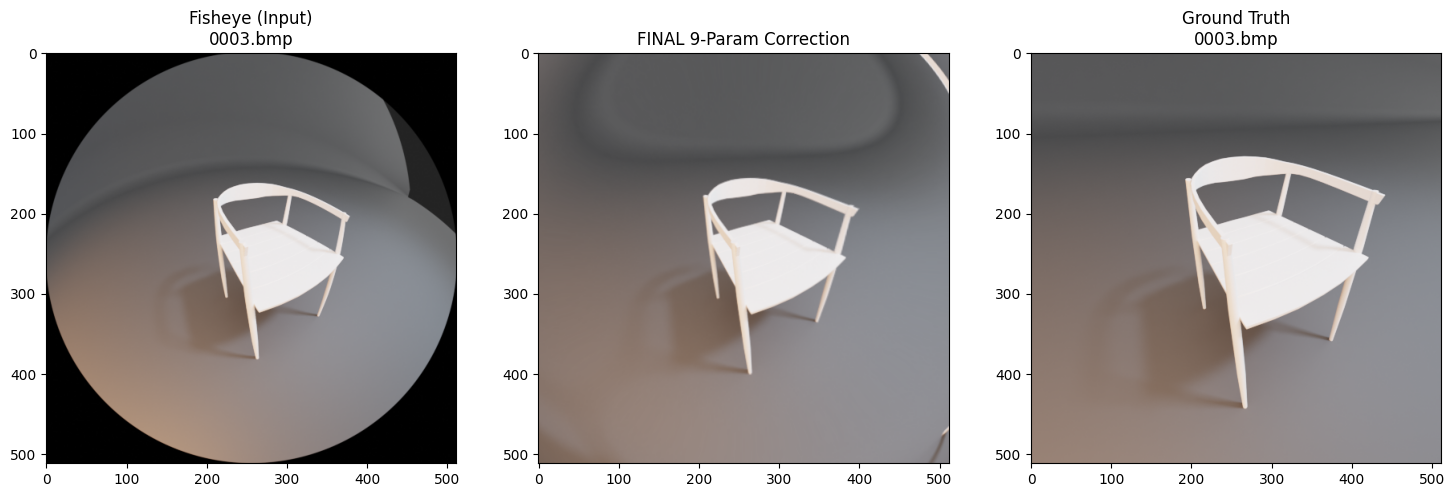

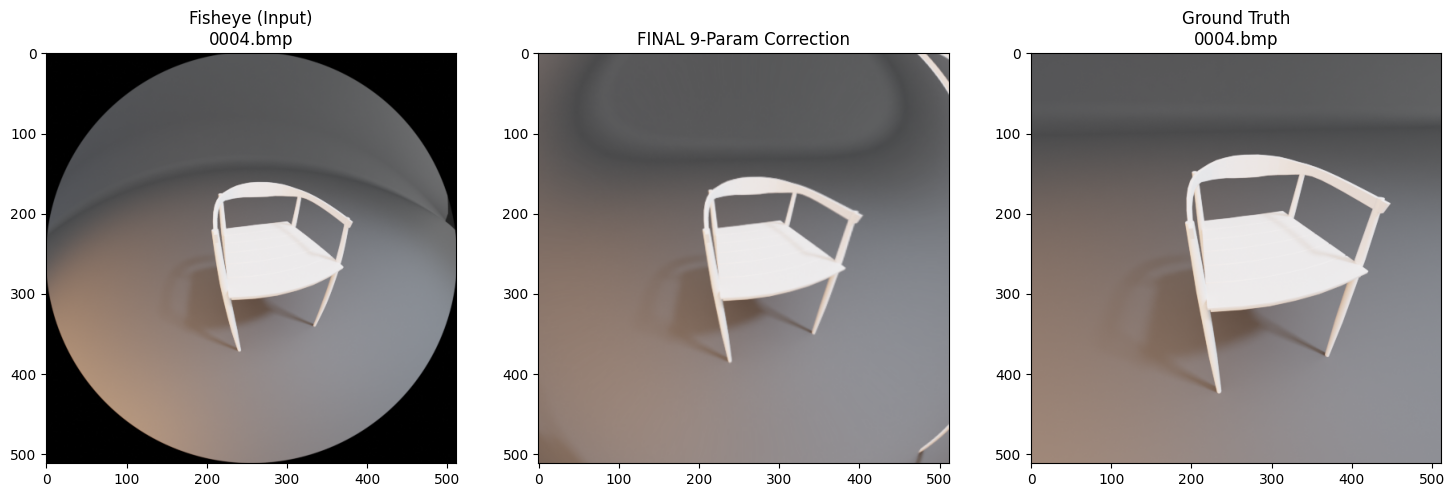

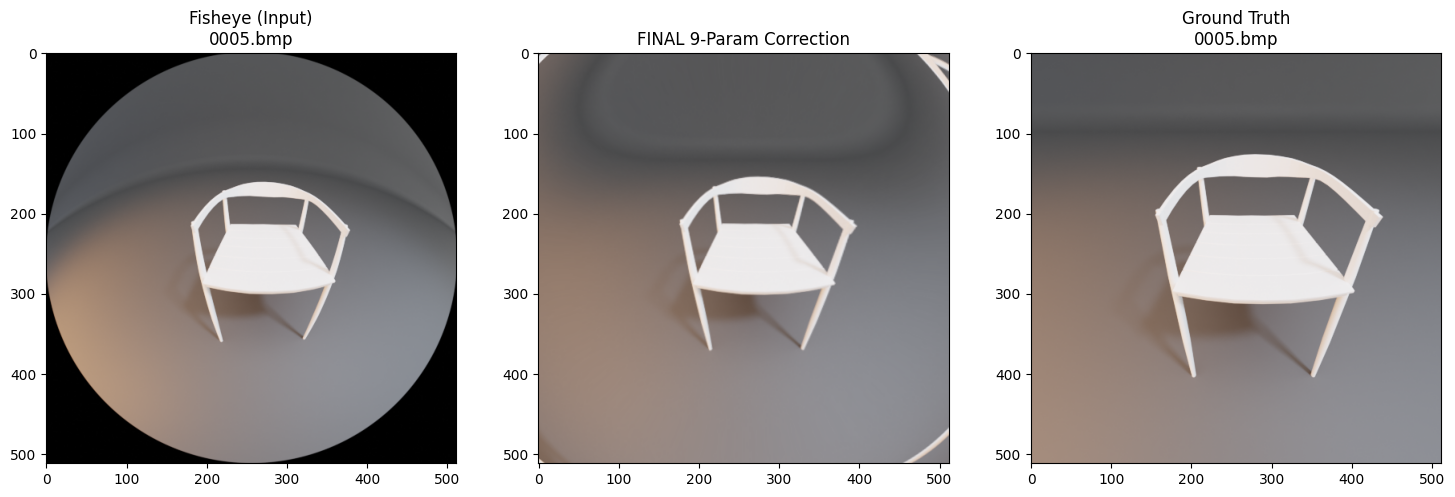

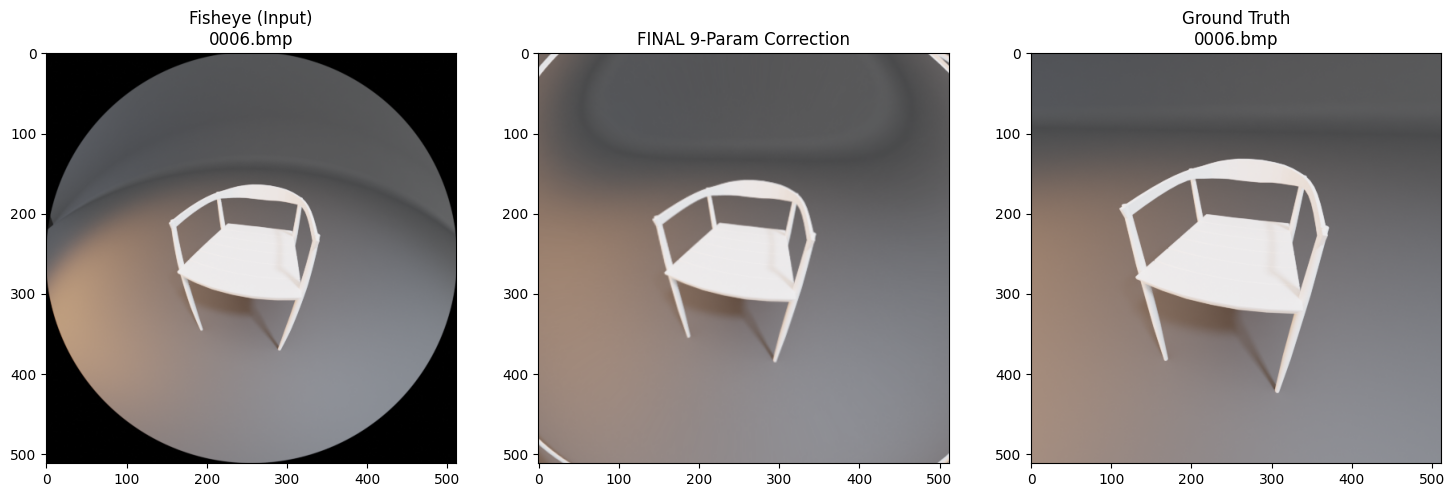

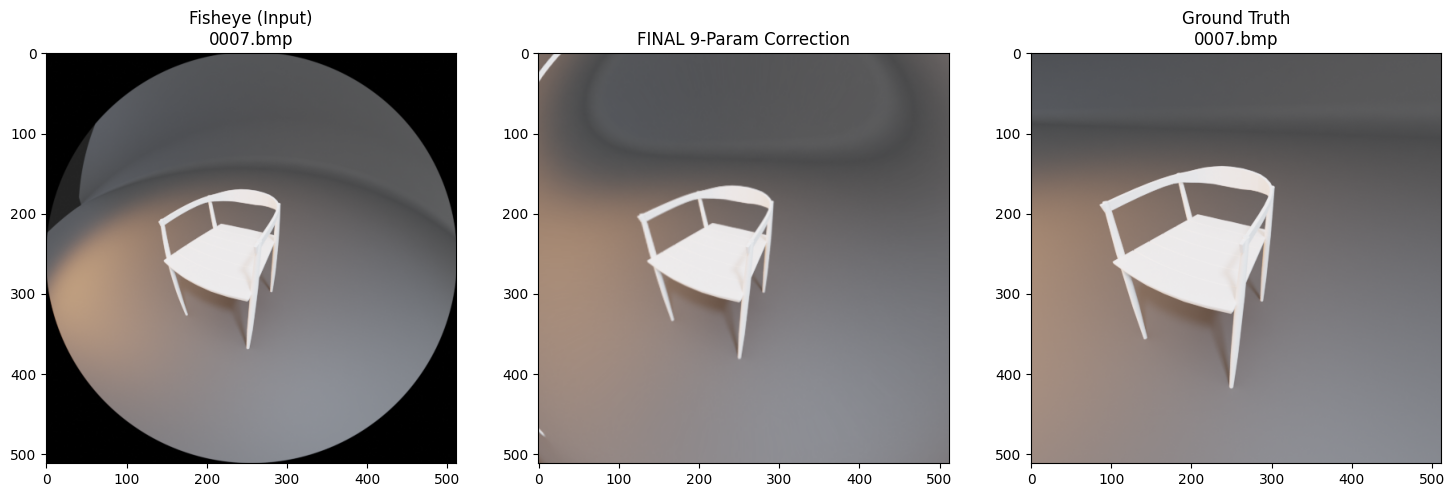

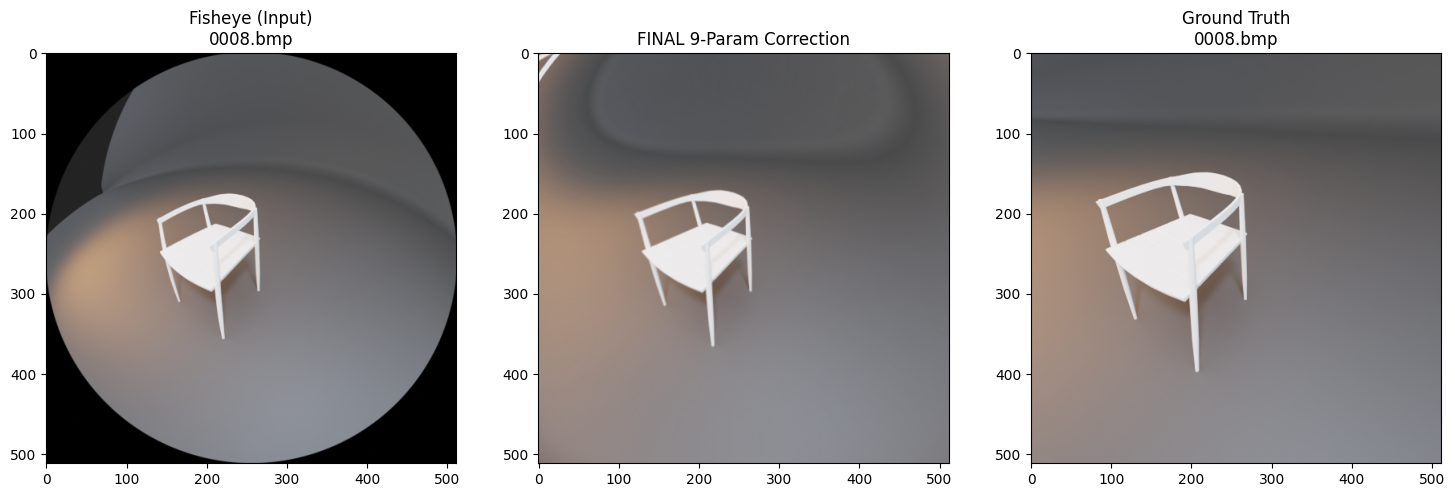

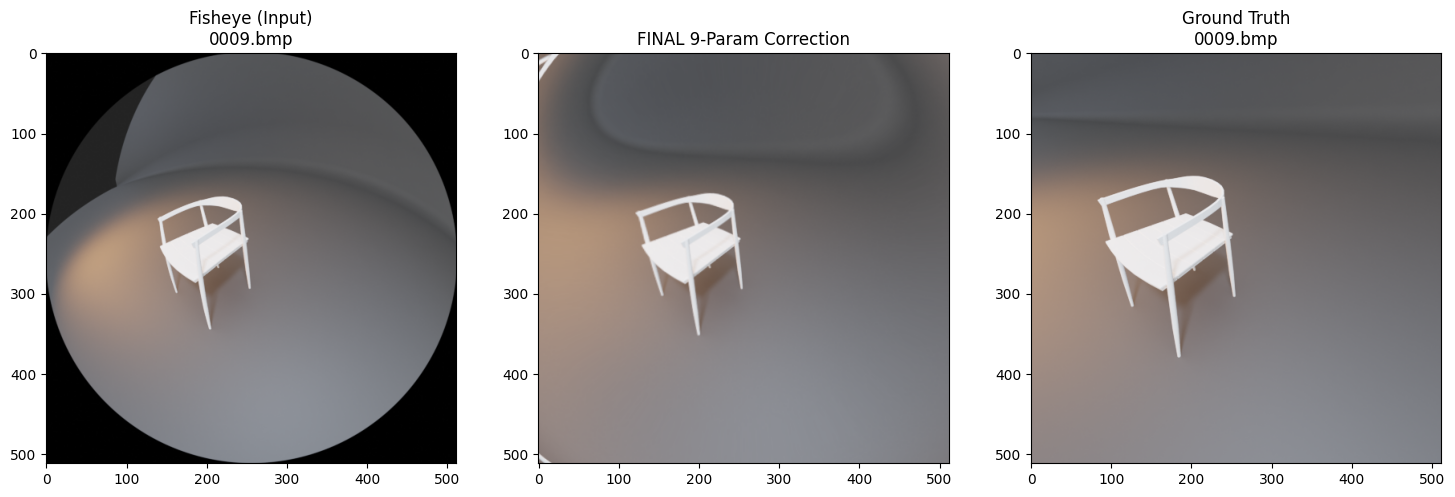

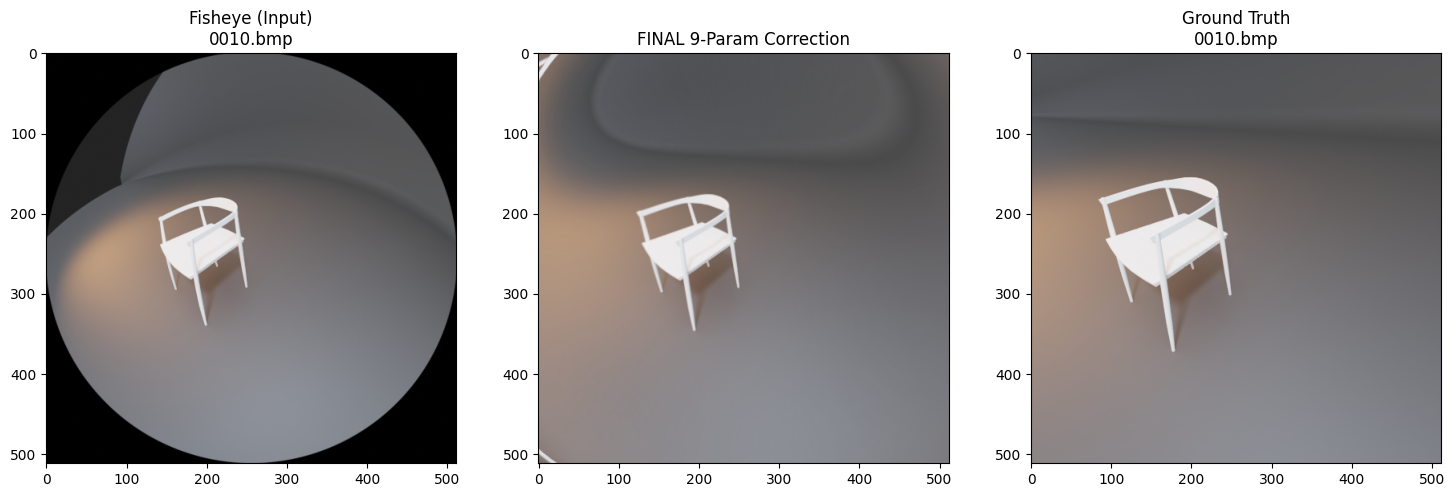

✅ All images corrected and saved.


In [69]:
import matplotlib.pyplot as plt
import cv2
import os

print("🚀 Applying FINAL optimized 9-parameter correction to all images...")

# (We assume fisheye_files, gt_files, output_dir, and
#  fisheye_dir are loaded from your very first cell)
# (We assume standard_model_correction is defined in Cell 1)
# (We assume best_params_final_9 is the result from Cell 3)

for i, fname in enumerate(fisheye_files):
    f_path = os.path.join(fisheye_dir, fname)
    g_path = os.path.join(gt_dir, gt_files[i])

    fisheye_img = cv2.imread(f_path)

    # Apply the final 9-parameter correction
    corrected_img, roi = standard_model_correction(fisheye_img, *best_params_final_9)

    # Save the corrected image
    cv2.imwrite(os.path.join(output_dir, fname), corrected_img)

    # Visual check for the first 2 images

    gt_img = cv2.imread(g_path)


    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(fisheye_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Fisheye (Input)\n{fname}")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(corrected_img, cv2.COLOR_BGR2RGB))
    plt.title("FINAL 9-Param Correction")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Ground Truth\n{gt_files[i]}")

    plt.show()

print("✅ All images corrected and saved.")

**Metrics Evaluation**

In [70]:
import cv2
import os
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error

base_dir = "/content/drive/MyDrive/FCV_PROJECT/Chair"

output_dir = os.path.join(base_dir, "corrected")
gt_dir = os.path.join(base_dir, "perspective")
category_name = os.path.basename(base_dir)

corrected_files = sorted(os.listdir(output_dir))
gt_files = sorted(os.listdir(gt_dir))

mse_scores = []
psnr_scores = []
ssim_scores = []
forr_scores = []

print(f"=== Processing category: {category_name} ===")

if len(corrected_files) != len(gt_files):
    print("❌ ERROR: Mismatch in file count between corrected and ground truth folders.")
elif not corrected_files:
     print(f"❌ ERROR: No files found in {output_dir}. Did you run Cell 4?")
else:
    for i in range(len(corrected_files)):

        corrected_path = os.path.join(output_dir, corrected_files[i])
        gt_path = os.path.join(gt_dir, gt_files[i])

        img_corrected = cv2.imread(corrected_path)
        img_gt = cv2.imread(gt_path)

        if img_corrected is None or img_gt is None:
            print(f"Warning: Could not read {corrected_files[i]} or {gt_files[i]}. Skipping.")
            continue

        print(f"  🔹 Processing image: {corrected_files[i]}")

        gt_gray = cv2.cvtColor(img_gt, cv2.COLOR_BGR2GRAY)
        corrected_gray = cv2.cvtColor(img_corrected, cv2.COLOR_BGR2GRAY)

        mse_val = mean_squared_error(gt_gray, corrected_gray)

        psnr_val = peak_signal_noise_ratio(gt_gray, corrected_gray, data_range=255)

        ssim_val = structural_similarity(gt_gray, corrected_gray, data_range=255)

        total_pixels = corrected_gray.size
        non_black_pixels = np.count_nonzero(corrected_gray > 0)
        forr_val = (non_black_pixels / total_pixels) * 100.0

        mse_scores.append(mse_val)
        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)
        forr_scores.append(forr_val)

        print(f"     MSE: {mse_val:.2f}  PSNR: {psnr_val:.2f} dB  SSIM: {ssim_val:.4f}  FoV Retention: {forr_val:.2f}%")

    if psnr_scores:
        avg_mse = np.mean(mse_scores)
        avg_psnr = np.mean(psnr_scores)
        avg_ssim = np.mean(ssim_scores)
        avg_forr = np.mean(forr_scores)

        print("\n" + "="*40)
        print(f"{category_name} summary: images processed: {len(psnr_scores)}")
        print(f"  Average MSE: {avg_mse:.2f}")
        print(f"  Average PSNR: {avg_psnr:.2f} dB")
        print(f"  Average SSIM: {avg_ssim:.4f}")
        print(f"  Average FoV Retention: {avg_forr:.2f}%")
        print("="*40)
    else:
        print("No images were processed.")

=== Processing category: Chair ===
  🔹 Processing image: 0001.bmp
     MSE: 898.32  PSNR: 18.60 dB  SSIM: 0.8737  FoV Retention: 100.00%
  🔹 Processing image: 0002.bmp
     MSE: 926.01  PSNR: 18.46 dB  SSIM: 0.8745  FoV Retention: 100.00%
  🔹 Processing image: 0003.bmp
     MSE: 986.66  PSNR: 18.19 dB  SSIM: 0.8808  FoV Retention: 100.00%
  🔹 Processing image: 0004.bmp
     MSE: 1153.08  PSNR: 17.51 dB  SSIM: 0.8731  FoV Retention: 100.00%
  🔹 Processing image: 0005.bmp
     MSE: 1332.99  PSNR: 16.88 dB  SSIM: 0.8612  FoV Retention: 100.00%
  🔹 Processing image: 0006.bmp
     MSE: 1198.53  PSNR: 17.34 dB  SSIM: 0.8722  FoV Retention: 100.00%
  🔹 Processing image: 0007.bmp
     MSE: 784.77  PSNR: 19.18 dB  SSIM: 0.9021  FoV Retention: 100.00%
  🔹 Processing image: 0008.bmp
     MSE: 571.97  PSNR: 20.56 dB  SSIM: 0.9157  FoV Retention: 100.00%
  🔹 Processing image: 0009.bmp
     MSE: 438.81  PSNR: 21.71 dB  SSIM: 0.9234  FoV Retention: 100.00%
  🔹 Processing image: 0010.bmp
     MSE: 405